# Running QCVV protocols
The main purpose of pyGSTi is to implement QCVV techniques that analyze some, often specific, experimental data to learn about a quantum processor.  Each such technique is called a "protocol" in pyGSTi, and this term roughly corresponds to its use in the literature.  To run a protocol on some data in pyGSTi, here's the general workflow:

1. Create an `ExperimentDesign` object.  An "experiment design" is just a description of a set of experiments.  It tells you **what circuits you need to run on your quantum processor**.  Most protocols require a certain structure to their circuits, or knowledge that their circuits have been drawn from a certain distribution, and thus have a corresponding experiment design type suited to them, e.g. `StandardGSTDesign` and `CliffordRBDesign`. 

2. Run or simulate the circuits demanded by the experiment design, and package the resulting data counts with the experiment design in a `ProtocolData` object.  This object constitutes the input to a protocol.

3. Create a `Protocol` object, usually corresponding to the type of experiment design, and pass your data object to its `run()` method.  The result is a `ProtocolResults` object containing the results of running the protocol along with all the inputs that went in to generating those results.

4. Look at the results object.  It can be used to make plots, generate reports, etc. 

Below are examples of how to run some of the protocols within pyGSTi.  You'll notice how, for the most part, they follow the same pattern given above.  Here's a list of the protocols for easy reference:

In [1]:
import pygsti
import numpy as np

## Gate set tomography
The most common reason to use pyGSTi is to run gate set tomography (GST).  The GST protocol uses sets of periodic circuits to probe, to a precision *linear* in the maximum-circuit length (i.e. depth), the gates on one or more of the qubits in a quantum processor.  For common gate sets with "model packs" that are built into pyGSTi, you only need to specify the maximum circuit length to construct an experiment design for GST.  In the example below, data is then simulated using a model with simple depolarizing errors.  The standard GST protocol is then run to produce a results object and then generate a report.   To learn more about GST, see the [GST Overview](../../start/FirstGST) and [GST Protocols](../gst/RunningGST) tutorials.

In [2]:
from pygsti.modelpacks import smq1Q_XY

# get experiment design
exp_design = smq1Q_XY.create_gst_experiment_design(max_max_length=316)  

# write an empty data object (creates a template to fill in)
pygsti.io.write_empty_protocol_data('../../../tutorial_files/test_gst_dir', exp_design, clobber_ok=True)

# fill in the template with simulated data (you would run the experiment and use actual data)
pygsti.io.fill_in_empty_dataset_with_fake_data(
    "../../../tutorial_files/test_gst_dir/data/dataset.txt",
    smq1Q_XY.target_model().depolarize(op_noise=0.01, spam_noise=0.001),
    num_samples=1000, seed=1234)

# load the data object back in, now with the experimental data
data = pygsti.io.read_data_from_dir('../../../tutorial_files/test_gst_dir')

# run the GST protocol on the data 
results = pygsti.protocols.StandardGST().run(data)

# create a report
report = pygsti.report.construct_standard_report(
    results, title="GST Overview Tutorial Example Report")
report.write_html("../../../tutorial_files/gettingStartedReport", connected=True)

-- Std Practice:  Iter 1 of 3  (full TP) --: 
  --- Iterative GST: [##################################################] 100.0%  964 circuits ---
-- Std Practice:  Iter 2 of 3  (CPTPLND) --: 
  --- Iterative GST: [##################################################] 100.0%  964 circuits ---
-- Std Practice:  Iter 3 of 3  (Target) --: 
Running idle tomography
Computing switchable properties
Found standard clifford compilation from smq1Q_XY
Found standard clifford compilation from smq1Q_XY
Found standard clifford compilation from smq1Q_XY


<env>/lib/python3.13/site-packages/plotly/offline/offline.py:150: UserWarning: 
Unrecognized config options supplied: ['showLink', 'linkText']
  warnings.warn(


Served with these docs: <a href="../../../reports/gettingStartedReport.html">gettingStartedReport</a>.

## Randomized benchmarking
Randomized benchmarking (RB) can be used to estimate the average per-Clifford error rate by fitting a simple curve to the data from randomized circuits of different depths.  To create the experiment design, the user specifies a `QubitProcessorSpec` object that describes the quantum processor (see the [ProcessorSpec tutorial](DescribeYourDevice)), the depths (in number of Clifford gates) to use, and the number of circuits at each depth.  The results from running the protocol are then used to create a plot of the RB decay curve along with the data.  For more information, see the [RB Overview tutorial](../rb/HowRBWorks).

- Sampling 50 circuits at CRB length 0 (1 of 4 depths) with seed 895919
- Sampling 50 circuits at CRB length 10 (2 of 4 depths) with seed 895969
- Sampling 50 circuits at CRB length 20 (3 of 4 depths) with seed 896019
- Sampling 50 circuits at CRB length 30 (4 of 4 depths) with seed 896069


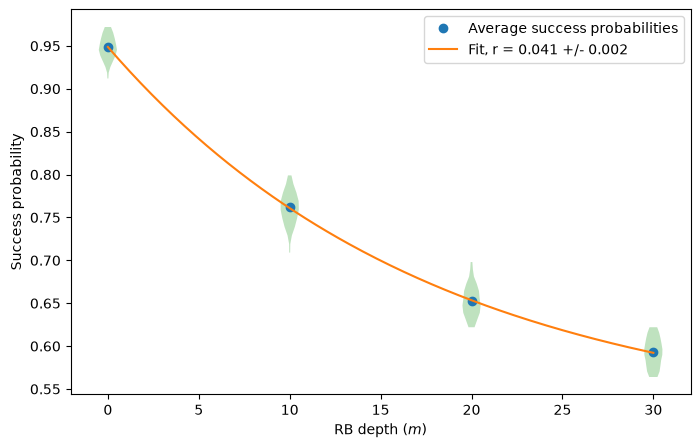

In [3]:
# define the quantum processor (or piece of a processor) we'll be doing RB on
qubit_labels = ['Q1']
gate_names = ['Gxpi2', 'Gxmpi2', 'Gypi2', 'Gympi2']
pspec = pygsti.processors.QubitProcessorSpec(len(qubit_labels), gate_names,
                 qubit_labels=qubit_labels)
depths = [0, 10, 20, 30]
circuits_per_depth = 50

# Create compilation rules from native gates to Cliffords
from pygsti.processors import CliffordCompilationRules as CCR
compilations = {'absolute': CCR.create_standard(pspec, 'absolute', ('paulis', '1Qcliffords'), verbosity=0),            
                'paulieq': CCR.create_standard(pspec, 'paulieq', ('1Qcliffords', 'allcnots'), verbosity=0)}

# create an experiment design
exp_design = pygsti.protocols.CliffordRBDesign(pspec, compilations, depths, circuits_per_depth)

# write an empty data object (creates a template to fill in)
pygsti.io.write_empty_protocol_data('../../../tutorial_files/test_rb_dir', exp_design, clobber_ok=True)

# fill in the template with simulated data (you would run the experiment and use actual data)
# Use a model with 1% depolarization on all gates
mdl_datagen = pygsti.models.create_crosstalk_free_model(pspec, depolarization_strengths={
    'Gxpi2': 0.01, 'Gxmpi2': 0.01, 'Gypi2': 0.01, 'Gympi2': 0.01
}, simulator="map")
pygsti.io.fill_in_empty_dataset_with_fake_data(
    "../../../tutorial_files/test_rb_dir/data/dataset.txt", mdl_datagen, num_samples=1000, seed=1234)

# load the data object back in, now with the experimental data
data = pygsti.io.read_data_from_dir('../../../tutorial_files/test_rb_dir')

#Run RB protocol                                                                                                                                                                                     
proto = pygsti.protocols.RB()
rbresults = proto.run(data)

#Create a RB plot
rbresults.plot()

## Model testing (see whether data agrees with a model)
GST fits a parameterized model to a data set (see above), which can require many circuits to be run, and take a long time to analyze.  It is also possible to create a model in pyGSTi and test how well that model fits a set of data.  The circuits used to make this comparison don't need to have any special structure, and the time required to perform the analysis it greatly reduce.  In the example below we create a simple 2-qubit model and test it against the output of five hand-selected sequences.  For more information on model testing, see the [model testing tutorial](../analysis/ModelTesting).  For more information about creating explicit models, see the [explicit model tutorial](../models/Models).

In [4]:
# create a dataset file that is just a list of circuits run and their outcomes
dataset_txt = \
"""## Columns = 00 count, 01 count, 10 count, 11 count
{}@(0,1)            100   0   0   0
Gx:0@(0,1)           55   5  40   0
Gx:0Gy:1@(0,1)       20  27  23  30
Gx:0^4@(0,1)         85   3  10   2
Gx:0Gcnot:0:1@(0,1)  45   1   4  50
"""
with open("../../../tutorial_files/Example_Short_Dataset_Protocols.txt","w") as f:
    f.write(dataset_txt)
ds = pygsti.io.read_dataset("../../../tutorial_files/Example_Short_Dataset_Protocols.txt")

# package the dataset into a data object, using the default experiment design
#  that has essentially no structure.
data = pygsti.protocols.ProtocolData(None, ds)

# create a model to test
pspec = pygsti.processors.QubitProcessorSpec(num_qubits=2, gate_names=['Gx', 'Gy', 'Gcnot'], geometry='line')
mdl_to_test = pygsti.models.create_explicit_model(pspec, ideal_gate_type='full TP')
mdl_to_test = mdl_to_test.depolarize(op_noise=0.01)  # a guess at what the noise is...
mdl_to_test.num_modeltest_params = 1  # treat as a model with one adjustable parameter (instead of .num_params)

# run the ModelTest protocol on the data
proto = pygsti.protocols.ModelTest(mdl_to_test)
results = proto.run(data)

print("Number of std-deviations away from expected = ", results.estimates['ModelTest'].misfit_sigma())

Reading ../../../tutorial_files/Example_Short_Dataset_Protocols.txt: 100%
Number of std-deviations away from expected =  10.530764512895061


## Robust phase estimation
Robust Phase Estimation (RPE) determines the phase of a target gate U by iterated action of that gate on a superposition of eigenstates of U.  Upwards of 30% error in counts can be tolerated, due to any cause (e.g., statistical noise or calibration error). See the [tutorial on RPE](../../advanced/specialist/RobustPhaseEstimation) for more details.

In this example, the π/2 phase of an X rotation is determined using only noisy X_pi/2 gates (and SPAM). Additional modelpacks for characterizing different phases of different gates will be made available in the future. In the meantime, if you wish to characterize, using RPE, the phase of a gate that is neither X_pi/2 nor Y_pi/2, please email either pygsti@sandia.gov or kmrudin@sandia.gov.

In [5]:
# An experiment design
from pygsti.modelpacks import smq1Q_Xpi2_rpe, smq1Q_XY
exp_design = smq1Q_Xpi2_rpe.create_rpe_experiment_design(max_max_length=64)

# write an empty data object (creates a template to fill in)
pygsti.io.write_empty_protocol_data('../../../tutorial_files/test_rpe_dir', exp_design, clobber_ok=True)

# fill in the template with simulated data (you would run the experiment and use actual data)
pygsti.io.fill_in_empty_dataset_with_fake_data(
    "../../../tutorial_files/test_rpe_dir/data/dataset.txt",
    smq1Q_XY.target_model().depolarize(op_noise=0.01, spam_noise=0.1),
    num_samples=1000, seed=1234)

# read the data object back in, now with the experimental data
data = pygsti.io.read_data_from_dir('../../../tutorial_files/test_rpe_dir/')

# Run the RPE Protocol
results = pygsti.protocols.rpe.RobustPhaseEstimation().run(data)

print(results.angle_estimate)

1.571377154153704


## Drift Characterization
Time-series data can be analyzed for significant indications of drift (time variance in circuit outcome probabilities).  See the [tutorial on drift characterization](../drift/DriftCharacterization) for more details.

In [6]:
from pygsti.modelpacks import smq1Q_XY
exp_design = smq1Q_XY.create_gst_experiment_design(max_max_length=4)
pygsti.io.write_empty_protocol_data('../../../tutorial_files/test_drift_dir', exp_design, clobber_ok=True)

# Simulate time dependent data (right now, this just uses a time-independent model so this is uninteresting)                                                       
datagen_model = smq1Q_XY.target_model().depolarize(op_noise=0.05, spam_noise=0.1)
datagen_model.sim = "map" # only map-type can generate time-dep data
                          # can also construct this as target_model(simulator="map") above
pygsti.io.fill_in_empty_dataset_with_fake_data('../../../tutorial_files/test_drift_dir/data/dataset.txt',
                                               datagen_model, num_samples=10, seed=2020, times=range(10))

gst_data = pygsti.io.read_data_from_dir('../../../tutorial_files/test_drift_dir')
stability_protocol = pygsti.protocols.StabilityAnalysis()
results = stability_protocol.run(gst_data)

report = pygsti.report.create_drift_report(results, title='Demo Drift Report')
report.write_html('../../../tutorial_files/DemoDriftReport', connected=True)

 - Formatting the data...done!
 - Calculating power spectra...

<repo>/pygsti/extras/drift/stabilityanalyzer.py:402: UserWarning: There are not enough timestamps per circuit to guarantee that the analysis will be reliable!
  _warnings.warn('There are not enough timestamps per circuit to'


done!
 - Running instability detection...done!
 - Running instability characterization...done!
*** Creating workspace ***
*** Generating switchboard ***


<env>/lib/python3.13/site-packages/plotly/offline/offline.py:150: UserWarning: 
Unrecognized config options supplied: ['showLink', 'linkText']
  warnings.warn(


Served with these docs: <a href="../../../reports/DemoDriftReport.html">DemoDriftReport</a>.

## What's next?
This concludes the overview of how the major protocols fit together. The high-level objects involved, namely `ExperimentDesign`, `ProtocolData`, `Protocol` and `ProtocolResults`, are convenient ways of working with pyGSTi's lower-level objects. The rest of this chapter takes those objects one at a time: [describing your device](DescribeYourDevice), [circuits](Circuits), [experiment designs](ExperimentDesigns), [data sets](DataSets), [simulating data](SimulatingData) and [files and directories](FilesAndDirectories). Target models come from [model packs](../../start/TargetModels), covered in Start here.